# MixUp Reproduction (CIFAR-10 / Fashion-MNIST)



## Step 0 — Install dependencies

In [3]:
!pip install torch torchvision tqdm

## Step 1 — Imports + basic utilities

In [4]:

# STEP 1: Imports + basic utils
import argparse, os, time, random, csv, math, glob
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm.auto import tqdm

def set_seed(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

def ensure_dir(p):
    os.makedirs(p, exist_ok=True)
    return p


## Step 2 — MixUp helpers (data + loss)

In [5]:

# STEP 2: MixUp helpers
# Returns mixed inputs, pairs of targets, and lambda.
def mixup_data(x, y, alpha=0.2, device=None):
    if alpha <= 0:
        lam = 1.0
        return x, y, y, lam
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    if device is None:
        device = x.device
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


## Step 3 — Dataloaders (CIFAR-10 & Fashion-MNIST)

In [6]:

# STEP 3: Data loaders
def get_dataloaders(dataset: str, batch_size: int, num_workers: int = 2):
    dataset = dataset.lower()
    normalize_cifar = transforms.Normalize((0.4914, 0.4822, 0.4465),
                                           (0.2023, 0.1994, 0.2010))
    normalize_fmnist = transforms.Normalize((0.2860, 0.2860, 0.2860),
                                            (0.3530, 0.3530, 0.3530))
    if dataset == "cifar10":
        train_tf = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            normalize_cifar,
        ])
        test_tf = transforms.Compose([
            transforms.ToTensor(),
            normalize_cifar,
        ])
        train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_tf)
        test_ds  = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_tf)
        num_classes = 10
    elif dataset == "fashionmnist":
        train_tf = transforms.Compose([
            transforms.Resize(32),
            transforms.Grayscale(num_output_channels=3),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            normalize_fmnist,
        ])
        test_tf = transforms.Compose([
            transforms.Resize(32),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            normalize_fmnist,
        ])
        train_ds = datasets.FashionMNIST(root="./data", train=True, download=True, transform=train_tf)
        test_ds  = datasets.FashionMNIST(root="./data", train=False, download=True, transform=test_tf)
        num_classes = 10
    else:
        raise ValueError("dataset must be one of: cifar10, fashionmnist")

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, test_loader, num_classes


### Step 3.5 — Dataset preview helpers (unnormalize + grid save)
Utilities to unnormalize CIFAR-10 / Fashion-MNIST for clean visuals and to save image grids.


In [7]:
# STEP 3.5: Preview helpers
import os, math, itertools
import torch
import torchvision
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

INV_NORM = {
    "cifar10": torchvision.transforms.Normalize(
        mean=[-0.4914/0.2023, -0.4822/0.1994, -0.4465/0.2010],
        std=[1/0.2023, 1/0.1994, 1/0.2010],
    ),
    "fashionmnist": torchvision.transforms.Normalize(
        mean=[-0.2860/0.3530, -0.2860/0.3530, -0.2860/0.3530],
        std=[1/0.3530, 1/0.3530, 1/0.3530],
    ),
}

CLASS_NAMES = {
    "cifar10": ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"],
    "fashionmnist": ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"],
}

def _ensure_save_dir(dataset, fallback="./outputs"):
    try:
        if dataset == "cifar10" and isinstance(out_c10, dict):
            return out_c10["dir"]
        if dataset == "fashionmnist" and 'out_fmnist' in globals() and isinstance(out_fmnist, dict):
            return out_fmnist["dir"]
    except NameError:
        pass
    d = os.path.join(fallback, f"{dataset}_preview")
    os.makedirs(d, exist_ok=True)
    return d

def save_grid(tensor_bchw, path, nrow, title=None):
    grid = make_grid(tensor_bchw, nrow=nrow, padding=2)
    npimg = grid.permute(1,2,0).cpu().numpy()
    plt.figure(figsize=(10,10))
    plt.imshow(npimg)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.savefig(path, bbox_inches="tight", dpi=200)
    plt.close()


### Step 3.6 — Random selection collages
Saves a grid of random samples from the test set for quick dataset pictures.


In [8]:
# STEP 3.6: Random selection collages
@torch.no_grad()
def random_collage(dataset, loader, total=100, nrow=10):
    inv = INV_NORM[dataset]
    xs = []
    for x, _ in loader:
        x = x[:min(len(x), total - sum(len(t) for t in xs))]
        x = torch.stack([inv(xx) for xx in x])
        xs.append(x)
        if sum(len(t) for t in xs) >= total:
            break
    imgs = torch.cat(xs, dim=0)[:total]
    save_dir = _ensure_save_dir(dataset)
    out = os.path.join(save_dir, f"{dataset}_random_grid.png")
    save_grid(imgs, out, nrow=nrow, title=f"{dataset.upper()}: Random selection")
    print("Saved:", out)

# Quick usage (reuses your loaders if available)
try:
    _ = train_c10
except NameError:
    train_c10, test_c10, _ = get_dataloaders("cifar10", batch_size=256)
try:
    _ = train_fm
except NameError:
    train_fm,  test_fm,  _ = get_dataloaders("fashionmnist", batch_size=256)

random_collage("cifar10", test_c10, total=100, nrow=10)
random_collage("fashionmnist", test_fm, total=100, nrow=10)


100%|██████████| 170M/170M [00:05<00:00, 29.2MB/s]
100%|██████████| 26.4M/26.4M [00:00<00:00, 116MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.88MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 61.6MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 30.6MB/s]


Saved: ./outputs/cifar10_preview/cifar10_random_grid.png


Saved: ./outputs/fashionmnist_preview/fashionmnist_random_grid.png


### Step 3.7 — Per-class tiles
Creates a grid of *k* samples per class plus an optional legend image.


In [9]:
# STEP 3.7: Per-class tiles
from PIL import Image, ImageDraw, ImageFont
import numpy as np

def per_class_tile(dataset, loader, k=10):
    names = CLASS_NAMES[dataset]
    inv = INV_NORM[dataset]
    buckets = {i: [] for i in range(len(names))}
    for x, y in loader:
        for xi, yi in zip(x, y):
            yi = int(yi)
            if len(buckets[yi]) < k:
                buckets[yi].append(inv(xi))
        if all(len(buckets[i]) >= k for i in buckets):
            break

    rows = []
    for c in range(len(names)):
        row = torch.stack([buckets[c][j] for j in range(k)], 0)
        rows.append(row)
    grid = torch.cat(rows, 0)
    outdir = _ensure_save_dir(dataset)
    png_path = os.path.join(outdir, f"{dataset}_per_class_{k}.png")
    save_grid(grid, png_path, nrow=k, title=f"{dataset.upper()}: {k} samples per class")
    print("Saved:", png_path)

    legend_h = 30 * len(names)
    legend = Image.new("RGB", (400, legend_h), "white")
    draw = ImageDraw.Draw(legend)
    try:
        font = ImageFont.truetype("DejaVuSans.ttf", 18)
    except Exception:
        font = None
    for i, name in enumerate(names):
        draw.text((10, 5 + i*30), f"{i}: {name}", fill=(0,0,0), font=font)
    legend_path = os.path.join(outdir, f"{dataset}_class_names.png")
    legend.save(legend_path)
    print("Saved:", legend_path)

# Define test_c10 and test_fm if they are not defined
try:
    _ = test_c10
except NameError:
    _, test_c10, _ = get_dataloaders("cifar10", batch_size=256)
try:
    _ = test_fm
except NameError:
    _, test_fm, _ = get_dataloaders("fashionmnist", batch_size=256)

per_class_tile("cifar10", test_c10, k=10)
per_class_tile("fashionmnist", test_fm, k=10)

Saved: ./outputs/cifar10_preview/cifar10_per_class_10.png
Saved: ./outputs/cifar10_preview/cifar10_class_names.png


Saved: ./outputs/fashionmnist_preview/fashionmnist_per_class_10.png
Saved: ./outputs/fashionmnist_preview/fashionmnist_class_names.png


### Step 3.8 — MixUp visualization (before → after)
Triptych: originals (row 1), partner originals (row 2), mixed (row 3).


In [10]:
# STEP 3.8: MixUp visualization
@torch.no_grad()
def visualize_mixup(dataset, loader, alpha=0.2, n=8):
    inv = INV_NORM[dataset]
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]
    mixed_x, y_a, y_b, lam = mixup_data(x, y, alpha=alpha, device=x.device)
    x_vis = torch.stack([inv(xx) for xx in x])
    mx_vis = torch.stack([inv(xx) for xx in mixed_x])
    idx = torch.randperm(n)
    partner = x_vis[idx]
    triptych = torch.cat([x_vis, partner, mx_vis], dim=0)
    save_dir = _ensure_save_dir(dataset)
    out = os.path.join(save_dir, f"{dataset}_mixup_demo_alpha{alpha:.2f}.png")
    save_grid(triptych, out, nrow=n, title=f"{dataset.upper()} MixUp demo (α={alpha:.2f}, λ≈{lam:.2f})")
    print("Saved:", out)

visualize_mixup("cifar10", test_c10, alpha=0.2, n=8)
visualize_mixup("fashionmnist", test_fm, alpha=0.2, n=8)


Saved: ./outputs/cifar10_preview/cifar10_mixup_demo_alpha0.20.png


Saved: ./outputs/fashionmnist_preview/fashionmnist_mixup_demo_alpha0.20.png


## Step 4 — Model (ResNet-18)

In [11]:

# STEP 4: Model
def get_model(num_classes: int):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


## Step 5 — Train & evaluate (with optional MixUp)

In [12]:

# STEP 5: Train & evaluate
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    running_acc, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(x)
        b = y.size(0)
        running_acc += accuracy(logits, y) * b
        n += b
    return running_acc / max(n, 1)

def train_one_run(dataset: str, use_mixup: bool, alpha: float, epochs: int, batch_size: int, lr: float, wd: float, outdir: str, seed: int = 42):
    set_seed(seed)
    device = get_device()
    train_loader, test_loader, num_classes = get_dataloaders(dataset, batch_size)
    model = get_model(num_classes).to(device)

    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_acc, best_path = 0.0, None
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    for epoch in range(1, epochs + 1):
        model.train()
        pbar = tqdm(train_loader, desc=f"[{dataset}] MixUp={use_mixup} α={alpha} | Epoch {epoch}/{epochs}", leave=False)
        for x, y in pbar:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            if use_mixup:
                mixed_x, y_a, y_b, lam = mixup_data(x, y, alpha=alpha, device=device)
                with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                    logits = model(mixed_x)
                    loss = mixup_criterion(criterion, logits, y_a, y_b, lam)
            else:
                with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                    logits = model(x)
                    loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            pbar.set_postfix(loss=f"{loss.item():.3f}")
        scheduler.step()

        test_acc = evaluate(model, test_loader, device)
        if test_acc > best_acc:
            best_acc = test_acc
            ensure_dir(outdir)
            tag = f"mixup{alpha:.2f}" if use_mixup else "baseline"
            best_path = os.path.join(outdir, f"{dataset}_{tag}_best.pt")
            torch.save({"model": model.state_dict(),
                        "acc": best_acc,
                        "epoch": epoch}, best_path)
        tqdm.write(f"Epoch {epoch:02d} | Test Acc: {test_acc*100:.2f}% (best {best_acc*100:.2f}%)")

    return best_acc, best_path


## Step 6 — Runner (executes baseline and MixUp, saves CSV)

In [13]:

# STEP 6: Runner
def write_csv_row(csv_path, row_dict, fieldnames):
    file_exists = os.path.isfile(csv_path)
    with open(csv_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not file_exists:
            writer.writeheader()
        writer.writerow(row_dict)

def run_experiment(
    dataset="cifar10",
    epochs=10,
    batch_size=128,
    lr=0.1,
    weight_decay=5e-4,
    alpha=0.2,
    seed=42,
    outdir="./outputs"
):
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = ensure_dir(os.path.join(outdir, f"{dataset}_{ts}"))
    csv_path = os.path.join(run_dir, "results.csv")
    fieldnames = ["timestamp", "dataset", "model", "epochs", "batch_size", "lr",
                  "weight_decay", "mixup_alpha", "use_mixup", "test_acc", "ckpt_path", "device"]

    print(f"Device: {get_device()}")
    print(f"Saving to: {run_dir}")

    # Baseline
    start = time.time()
    acc_base, ckpt_base = train_one_run(
        dataset=dataset,
        use_mixup=False,
        alpha=0.0,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        wd=weight_decay,
        outdir=run_dir,
        seed=seed
    )
    write_csv_row(csv_path, {
        "timestamp": ts,
        "dataset": dataset,
        "model": "resnet18",
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": lr,
        "weight_decay": weight_decay,
        "mixup_alpha": 0.0,
        "use_mixup": False,
        "test_acc": round(acc_base * 100, 2),
        "ckpt_path": ckpt_base,
        "device": str(get_device())
    }, fieldnames)
    print(f"[BASELINE] Test Acc: {acc_base*100:.2f}% | ckpt: {ckpt_base} | time: {time.time()-start:.1f}s")

    # MixUp
    start = time.time()
    acc_mix, ckpt_mix = train_one_run(
        dataset=dataset,
        use_mixup=True,
        alpha=alpha,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        wd=weight_decay,
        outdir=run_dir,
        seed=seed
    )
    write_csv_row(csv_path, {
        "timestamp": ts,
        "dataset": dataset,
        "model": "resnet18",
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": lr,
        "weight_decay": weight_decay,
        "mixup_alpha": alpha,
        "use_mixup": True,
        "test_acc": round(acc_mix * 100, 2),
        "ckpt_path": ckpt_mix,
        "device": str(get_device())
    }, fieldnames)
    print(f"[MixUp α={alpha}] Test Acc: {acc_mix*100:.2f}% | ckpt: {ckpt_mix} | time: {time.time()-start:.1f}s")

    # Summary
    diff = (acc_mix - acc_base) * 100
    print("\n=== SUMMARY ===")
    print(f"Dataset: {dataset}")
    print(f"Baseline Acc:  {acc_base*100:.2f}%")
    print(f"MixUp Acc:     {acc_mix*100:.2f}% (α={alpha})")
    print(f"Δ Improvement: {diff:.2f} pp")
    print(f"Results CSV:   {csv_path}")
    print(f"Checkpoints:   {ckpt_base} , {ckpt_mix}")

    return {"csv": csv_path, "baseline": acc_base, "mixup": acc_mix, "dir": run_dir}


## Step 7 — Run on CIFAR-10

In [15]:

# STEP 7: CIFAR-10 run
out_c10 = run_experiment(
    dataset="cifar10",
    epochs=10,
    batch_size=128,
    lr=0.1,
    weight_decay=5e-4,
    alpha=0.2,
    seed=42,
    outdir="./outputs"
)


Device: cuda
Saving to: ./outputs/cifar10_20251105_091444


/tmp/ipython-input-1621547253.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


[cifar10] MixUp=False α=0.0 | Epoch 1/10:   0%|          | 0/391 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c40cc71cb80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c40cc71cb80>assert self._parent_pid == os.getpid(), 'can only test a child process'

  Traceback (most recent call last):
     File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
        self._shutdown_workers()
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive(): 
  ^  ^ ^^ ^ ^^^^^^^Exception ign

Epoch 01 | Test Acc: 41.30% (best 41.30%)


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c40cc71cb80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
   Exception ignored in:   <function _MultiProcessingDataLoaderIter.__del__ at 0x7c40cc71cb80> 
 Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
^    ^^if w.is_alive():
^ ^ ^ ^ 
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      assert self._parent_pid == os.getpid(), 'can only test a child process'^
^  ^^  ^ ^^  ^   ^ ^^^^^^^^
^^^  Fi

Epoch 09 | Test Acc: 76.10% (best 76.10%)


[cifar10] MixUp=True α=0.2 | Epoch 10/10:   0%|          | 0/391 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c40cc71cb80>Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c40cc71cb80>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
        self._shutdown_workers()self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
     if w.is_alive(): 
          ^^ ^ ^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'

  File "/usr/lib/python

Epoch 10 | Test Acc: 77.37% (best 77.37%)
[MixUp α=0.2] Test Acc: 77.37% | ckpt: ./outputs/cifar10_20251105_091444/cifar10_mixup0.20_best.pt | time: 314.6s

=== SUMMARY ===
Dataset: cifar10
Baseline Acc:  78.28%
MixUp Acc:     77.37% (α=0.2)
Δ Improvement: -0.91 pp
Results CSV:   ./outputs/cifar10_20251105_091444/results.csv
Checkpoints:   ./outputs/cifar10_20251105_091444/cifar10_baseline_best.pt , ./outputs/cifar10_20251105_091444/cifar10_mixup0.20_best.pt


## Step 8 — (Optional) Run on Fashion-MNIST

In [16]:

# STEP 8: Fashion-MNIST run (optional)
out_fmnist = run_experiment(
    dataset="fashionmnist",
    epochs=10,
    batch_size=128,
    lr=0.1,
    weight_decay=5e-4,
    alpha=0.2,
    seed=42,
    outdir="./outputs"
)


Device: cuda
Saving to: ./outputs/fashionmnist_20251105_092728


/tmp/ipython-input-1621547253.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


[fashionmnist] MixUp=False α=0.0 | Epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c40cc71cb80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c40cc71cb80>^^

Traceback (most recent call last):
AssertionError: can only test a child process
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c40cc71cb80

Epoch 01 | Test Acc: 84.56% (best 84.56%)


...

Epoch 08 | Test Acc: 91.18% (best 91.18%)


[fashionmnist] MixUp=True α=0.2 | Epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 09 | Test Acc: 91.54% (best 91.54%)


[fashionmnist] MixUp=True α=0.2 | Epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10 | Test Acc: 91.68% (best 91.68%)
[MixUp α=0.2] Test Acc: 91.68% | ckpt: ./outputs/fashionmnist_20251105_092728/fashionmnist_mixup0.20_best.pt | time: 405.0s

=== SUMMARY ===
Dataset: fashionmnist
Baseline Acc:  92.46%
MixUp Acc:     91.68% (α=0.2)
Δ Improvement: -0.78 pp
Results CSV:   ./outputs/fashionmnist_20251105_092728/results.csv
Checkpoints:   ./outputs/fashionmnist_20251105_092728/fashionmnist_baseline_best.pt , ./outputs/fashionmnist_20251105_092728/fashionmnist_mixup0.20_best.pt


## Step 9 — Preview results CSV

In [17]:

# STEP 9: Load and preview results CSV
import pandas as pd
pd.read_csv(out_c10["csv"])


,timestamp,dataset,model,epochs,batch_size,lr,weight_decay,mixup_alpha,use_mixup,test_acc,ckpt_path,device
0,20251105_091444,cifar10,resnet18,10,128,0.1,0.0005,0.0,False,78.28,./outputs/cifar10_20251105_091444/cifar10_base...,cuda
1,20251105_091444,cifar10,resnet18,10,128,0.1,0.0005,0.2,True,77.37,./outputs/cifar10_20251105_091444/cifar10_mixu...,cuda


## Step 10 — Build a clean summary and plot Baseline vs MixUp

In [18]:

# STEP 10: Summary & table
import pandas as pd, os, glob
all_runs = []
for csv_path in glob.glob(os.path.join("./outputs", "*", "results.csv")):
    df = pd.read_csv(csv_path)
    df["run_dir"] = os.path.dirname(csv_path)
    all_runs.append(df)
if all_runs:
    all_df = pd.concat(all_runs, ignore_index=True)
    summary = (
        all_df.pivot_table(index=["dataset", "model", "epochs", "batch_size", "lr", "weight_decay"],
                           columns="use_mixup", values="test_acc", aggfunc="max")
        .rename(columns={False: "Baseline (%)", True: "MixUp (%)"})
        .reset_index()
    )
    if "Baseline (%)" in summary and "MixUp (%)" in summary:
        summary["Δ Improvement (pp)"] = summary["MixUp (%)"] - summary["Baseline (%)"]
    summary
else:
    print("No results found yet. Run Step 7/8 first.")


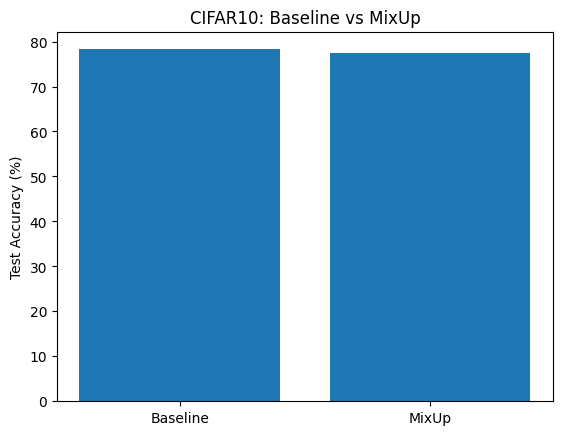

Saved figure to: ./outputs/cifar10_20251105_091444/cifar10_baseline_vs_mixup.png


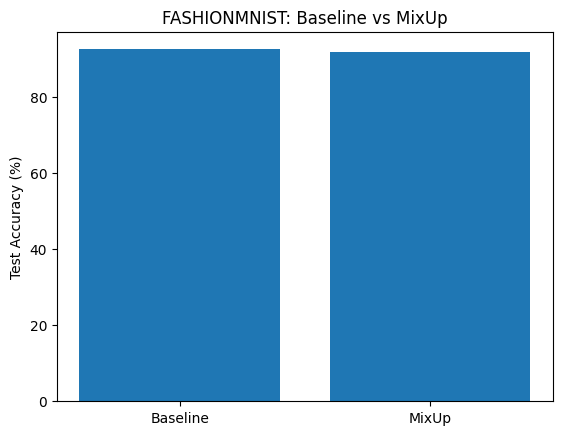

Saved figure to: ./outputs/cifar10_20251105_091444/fashionmnist_baseline_vs_mixup.png


In [20]:

# Plot for each dataset
import matplotlib.pyplot as plt, os
def plot_results(summary_df, save_dir="./outputs"):
    if summary_df is None or len(summary_df)==0:
        print("No summary to plot.")
        return
    for idx in range(len(summary_df)):
        row = summary_df.iloc[idx]
        ds = row["dataset"]
        values = [float(row["Baseline (%)"]), float(row["MixUp (%)"])]
        labels = ["Baseline", "MixUp"]
        plt.figure()
        plt.bar(labels, values)
        plt.ylabel("Test Accuracy (%)")
        plt.title(f"{ds.upper()}: Baseline vs MixUp")
        outpath = os.path.join(save_dir, f"{ds}_baseline_vs_mixup.png")
        plt.savefig(outpath, bbox_inches="tight", dpi=200)
        plt.show()
        print("Saved figure to:", outpath)

try:
    plot_results(summary, save_dir=out_c10["dir"] if isinstance(out_c10, dict) else "./outputs")
except NameError:
    print("Run the previous cell to create 'summary' first.")
